# 9주차_통계 기반 분석 방법론

- ANOVA(Analysis of Variance)

---

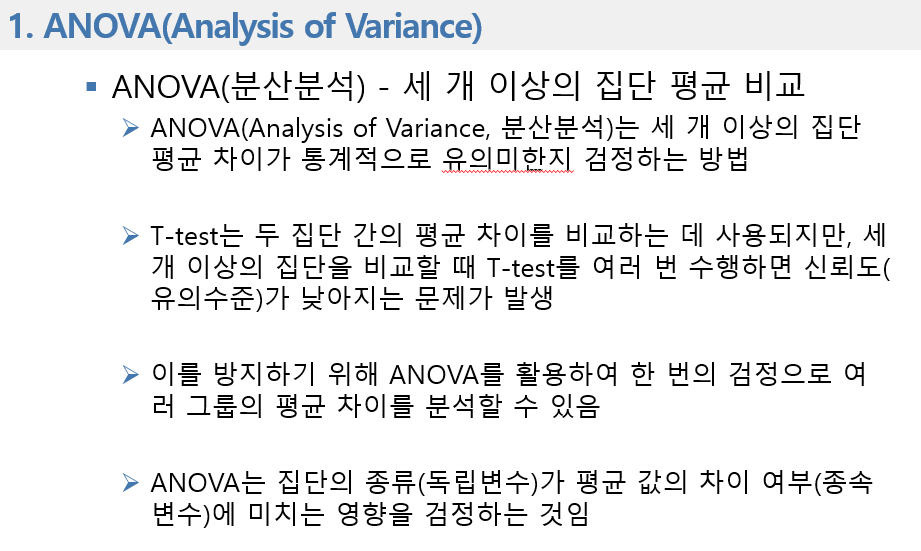

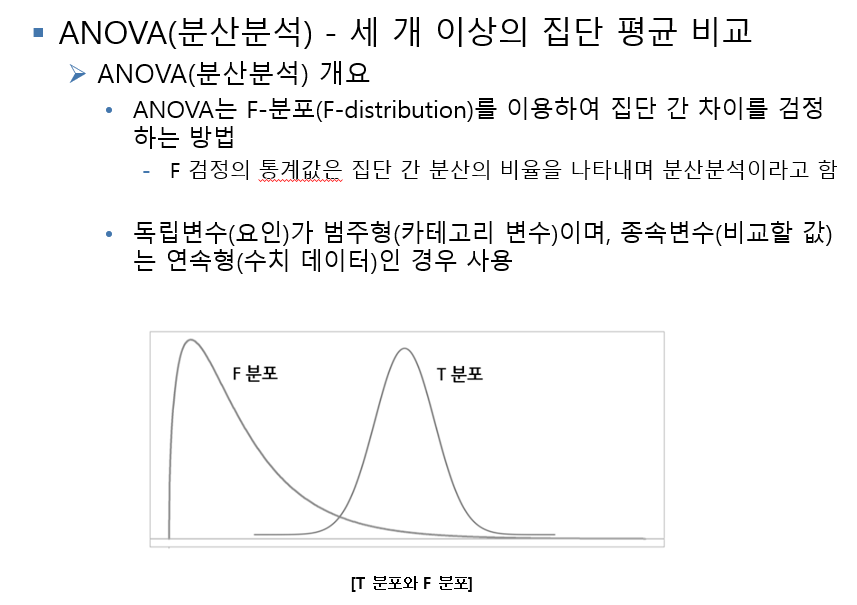

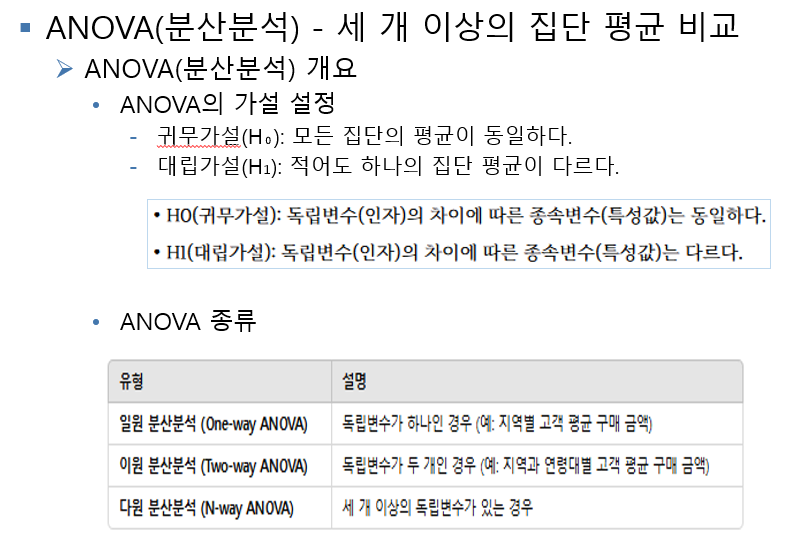

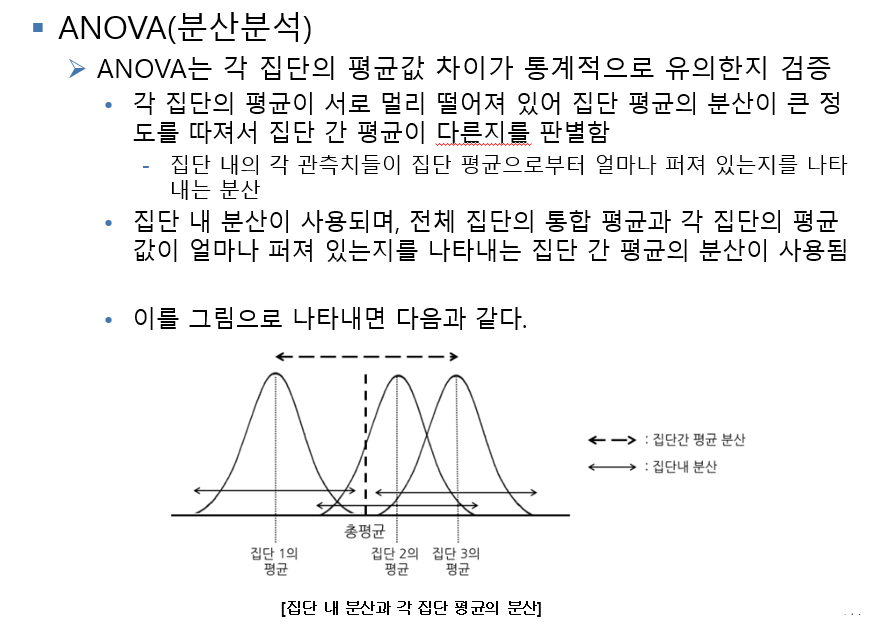

---

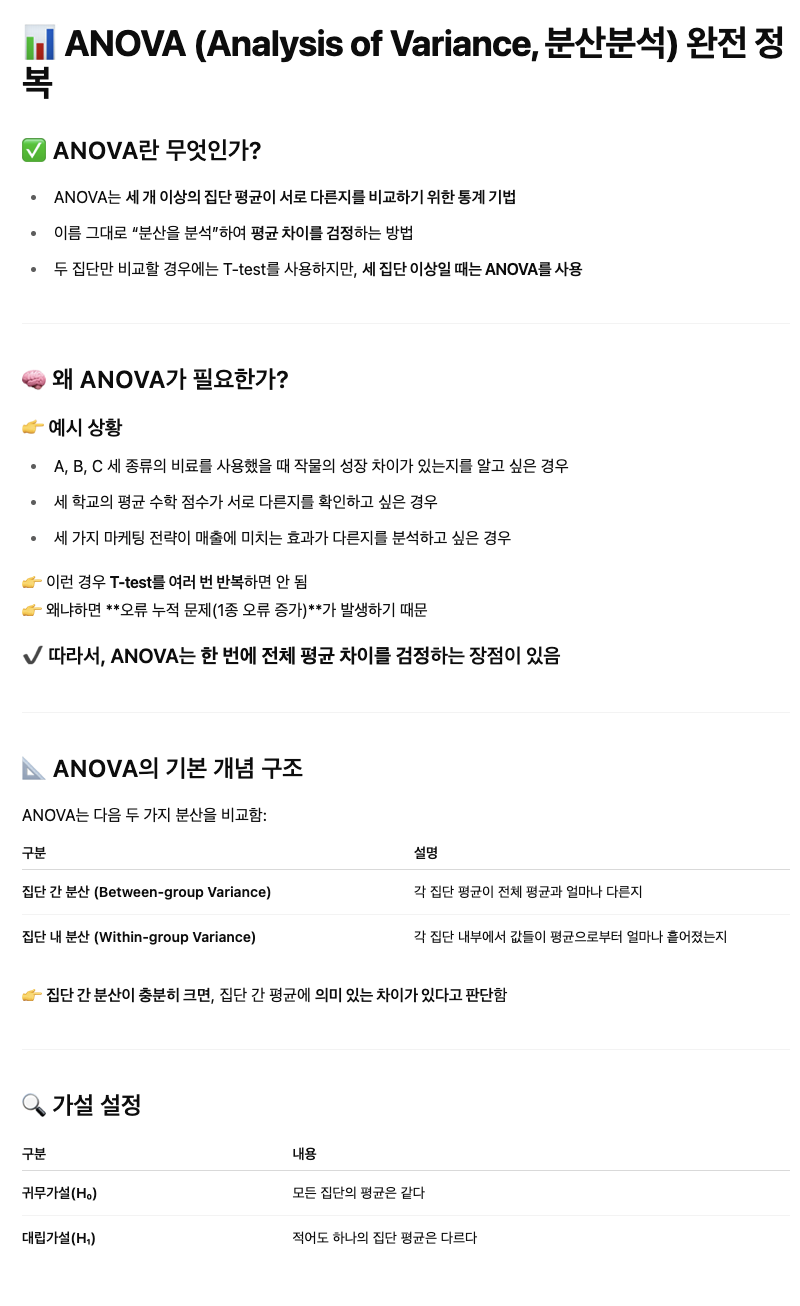

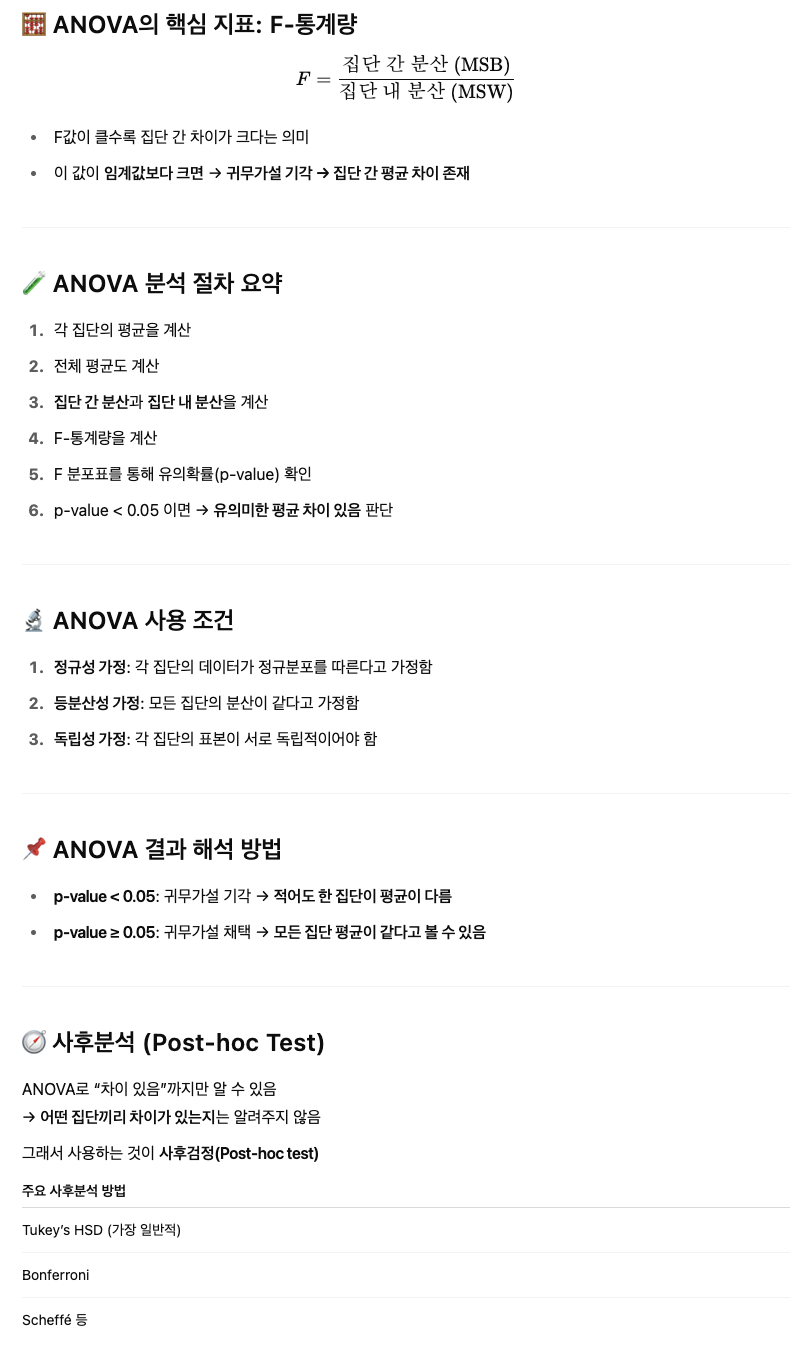

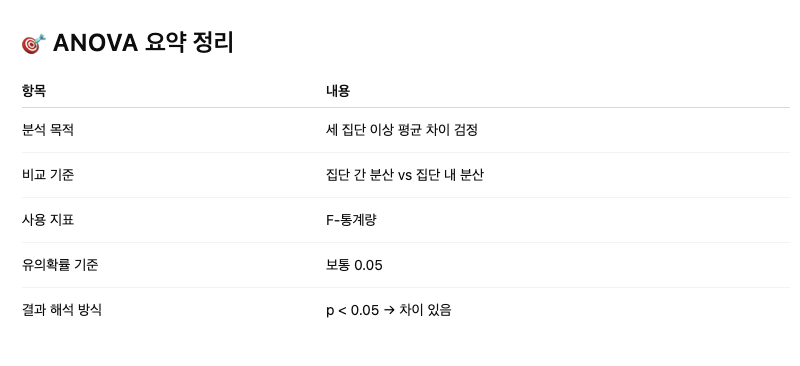

In [ ]:
# 필요한 패키지 설치 및 불러오기

from statsmodels.formula.api import ols  
# statsmodels 패키지의 formula API 중 OLS(Ordinary Least Squares, 최소제곱법) 모델을 불러오는 명령문
# OLS는 선형회귀 분석 또는 분산분석(ANOVA)에서 사용되며, R과 유사한 '수식 기반 모델링'을 지원함
# 예: ols('결과변수 ~ 그룹', data=데이터프레임).fit()

from statsmodels.stats.anova import anova_lm  
# 분산분석(ANOVA: Analysis of Variance)을 수행하는 함수인 anova_lm을 불러오는 명령문
# 선형 모델(OLS) 객체를 입력받아, 그룹 간 평균 차이가 통계적으로 유의미한지를 검정함
# 예: anova_lm(ols_model) → F값, p값, 제곱합 등 분산분석표 출력

from statsmodels.stats.multicomp import pairwise_tukeyhsd  
# 사후검정(Post-hoc test) 중 하나인 Tukey의 HSD(Honestly Significant Difference) 검정을 수행하는 함수
# ANOVA에서 유의미한 차이가 있는 경우, 어떤 그룹 간에 차이가 존재하는지를 추가적으로 파악하기 위해 사용됨
# 예: pairwise_tukeyhsd(endog=데이터, groups=그룹변수, alpha=0.05)

import scipy.stats  
# scipy 라이브러리의 통계 모듈을 불러오는 명령문
# 다양한 통계검정 함수(t-test, 카이제곱, 정규성검정 등)를 포함하고 있음

import scipy.stats as stats  
# 위와 동일한 모듈을 'stats'라는 별칭으로 불러오는 명령문
# 보다 짧고 명확한 호출이 가능함 (예: stats.ttest_ind)

from scipy.stats import ttest_ind  
# 독립표본 t-test를 수행하는 함수 ttest_ind를 직접 불러오는 명령문
# 두 독립된 집단 간 평균 차이가 통계적으로 유의한지를 검정함
# 예: ttest_ind(집단1, 집단2, equal_var=False)

import pandas as pd  
# 데이터프레임 기반 데이터 처리와 분석을 위한 pandas 라이브러리를 불러오는 명령문
# csv 파일 읽기, 그룹 연산, 통계 요약 등의 데이터 처리에 필수적으로 사용됨


| 용도 | 사용 함수 또는 라이브러리 |
| --- | --- |
| **선형모델 구축** | `ols()` – 분산분석 또는 회귀 분석용 공식 모델 생성 |
| **분산분석 수행** | `anova_lm()` – 그룹 간 평균 차이 검정 (F-test 기반) |
| **사후 분석** | `pairwise_tukeyhsd()` – 어떤 그룹 간에 차이 있는지 탐색 |
| **기초통계 검정** | `ttest_ind()`, `scipy.stats` – 정규성, 평균 차이 등 다양한 검정 |

In [8]:
# 데이터 불러오기
# https://www.kaggle.com/datasets/sewonghwang/golf-ball-testing
df = pd.read_csv("../../../main/datasets/Golf_test.csv")

# 데이터 샘플 확인
df.head()

,TypeA_before,TypeA_after,TypeB_before,TypeB_after,TypeC_before,TypeC_after
0,277,264,265,268,267,268
1,269,261,264,267,264,269
2,263,267,269,272,283,283
3,266,272,274,277,287,266
4,262,258,261,264,275,266


### 이후 이어지는 분석 흐름 예시

| 단계 | 설명 | 관련 함수 |
| --- | --- | --- |
| ① | 정규성 검정 | `shapiro()` |
| ② | 등분산성 검정 | `bartlett()` or `levene()` |
| ③ | 평균 차이 검정 (2집단) | `ttest_rel()`, `ttest_ind()` |
| ④ | 평균 차이 검정 (3집단 이상) | `ols()`, `anova_lm()` |
| ⑤ | 사후 검정 | `pairwise_tukeyhsd()` |
| ⑥ | 시각화 | `boxplot`, `violinplot`, `lineplot` 등 |

In [9]:
# stats 패키지를 활용한 아노바(ANOVA) 검정 수행

F_statistic, pVal = stats.f_oneway(df['TypeA_before'], 
                                   df['TypeB_before'], 
                                   df['TypeC_before'])  
# scipy의 stats 모듈에서 제공하는 f_oneway() 함수를 이용해 **일원분산분석(One-way ANOVA)**를 수행하는 명령문
# 세 그룹(TypeA, TypeB, TypeC의 사전 측정값) 간의 평균 차이가 통계적으로 유의미한지를 검정함

# 일원분산분석의 기본 가설 구조:
#   - 귀무가설(H₀): 모든 그룹의 평균이 같다 (μ₁ = μ₂ = μ₃)
#   - 대립가설(H₁): 적어도 하나의 그룹 평균이 다르다

# 이 함수는 다음 값을 반환함:
#   - F_statistic: 그룹 간 평균 차이를 나타내는 F 검정 통계량
#   - pVal: p-value (유의확률), 귀무가설을 기각할 수 있는지 판단하는 기준 수치

# 이때 f_oneway()는 다음과 같은 전제 조건이 필요함:
#   1) 각 그룹은 서로 독립적이어야 함
#   2) 각 그룹은 정규분포를 따라야 함
#   3) 각 그룹은 등분산성을 가져야 함

print('일원분산분석 결과 : F={0:.1f}, p={1:.5f}'.format(F_statistic, pVal))  
# 분석 결과를 사람이 읽기 쉽도록 포맷팅하여 출력하는 명령문
# F 통계량은 소수점 첫째 자리까지, p-value는 다섯째 자리까지 표시함
# 결과 해석 기준:
#   - p-value < 0.05 → 귀무가설 기각 → 그룹 간 평균에 유의한 차이 있음
#   - p-value ≥ 0.05 → 귀무가설 채택 → 평균 차이가 통계적으로 유의하지 않음


일원분산분석 결과 : F=4.2, p=0.01652


### 일원분산분석(ANOVA) 결과

| 항목 | 값 | 해석 |
| --- | --- | --- |
| **검정 방법** | 일원분산분석 (One-way ANOVA) | 세 집단의 평균 차이를 동시에 검정하는 통계 방법 |
| **비교한 그룹** | TypeA_before, TypeB_before, TypeC_before | 세 종류의 골프공 사전 데이터 |
| **귀무가설(H₀)** | 모든 그룹의 평균이 같다 (μ₁ = μ₂ = μ₃) | 차이가 없다는 가정 |
| **대립가설(H₁)** | 적어도 하나의 그룹 평균이 다르다 | 하나 이상의 평균 차이가 존재함을 주장 |
| **F 통계량** | 4.2 | 그룹 간 평균 차이에 대한 분산비 → 클수록 귀무가설 기각 가능성 증가 |
| **p-value** | 0.01652 | 유의확률 → 귀무가설을 기각할 수 있는 통계적 기준 |
| **유의수준(α)** | 0.05 (기본 기준) | 기준선 이하일 경우 귀무가설을 기각함 |
| **판단** | 0.01652 < 0.05 → 귀무가설 기각 | 세 그룹 중 적어도 하나는 평균이 다름 |
| **결론** | 세 골프공 타입 간 평균 차이가 통계적으로 유의함 | 단, 어떤 그룹 간 차이인지는 사후 검정을 통해 추가 판단 필요 |

In [10]:
# 데이터 재구조화

df2 = pd.melt(df)  
# 원본 데이터프레임(df)을 '긴 형식(long format)'으로 변환하는 명령문
# melt는 여러 열(column)을 하나의 열로 녹여내어 → 두 개의 열('variable', 'value')로 바꾸는 역할을 수행함
# 'variable' 열에는 원래의 열 이름(TypeA_before, TypeA_after 등)이 들어가며,
# 'value' 열에는 각 열의 실제 수치 값이 들어감
# 통계 분석이나 시각화를 위해 데이터가 열 형태로 너무 많을 경우, 이를 변수명/값으로 재구조화하는 과정임

df2 = df2[df2['variable'].isin(['TypeA_before', 'TypeB_before', 'TypeC_before'])]  
# 'variable' 열이 TypeA_before, TypeB_before, TypeC_before 중 하나인 행만 필터링하는 명령문
# 즉, 사전(before) 실험값들만 남기고 나머지 측정 항목(TypeX_after 등)은 제거함
# 이는 ANOVA 분석이나 시각화를 '사전값 기준으로만' 수행하려는 목적에 해당함

df2.head()  
# 재구조화된 데이터프레임(df2)의 상위 5개 행을 확인하는 명령문
# melt 후 구조가 올바르게 변경되었는지, 필터링이 정확히 수행되었는지를 시각적으로 확인함

,variable,value
0,TypeA_before,277
1,TypeA_before,269
2,TypeA_before,263
3,TypeA_before,266
4,TypeA_before,262


In [11]:
# ols 패키지를 이용한 아노바(ANOVA) 검정 수행

model = ols('value ~ C(variable)', df2).fit()  
# statsmodels의 formula API를 이용해 OLS(최소제곱법) 기반 선형모델을 생성하고 학습하는 명령문
# 'value ~ C(variable)'은 종속변수 value가 범주형 독립변수 variable에 따라 어떻게 달라지는지를 모델링함
# 여기서 C(variable)은 variable이 범주형 변수임을 명시적으로 선언하는 코드임 (즉, 그룹별 평균 차이를 고려하겠다는 뜻)
# .fit()을 통해 OLS 모델을 학습하고, 그룹 간 평균 차이에 기반한 분산 구조를 계산함

print(anova_lm(model))  
# 학습된 선형모델을 기반으로 분산분석(ANOVA)을 수행하여 결과표를 출력하는 명령문
# anova_lm() 함수는 다음과 같은 항목을 포함한 분산분석표를 출력함:
#   - **df**: 각 소스(그룹, 잔차)의 자유도
#   - **sum_sq**: 제곱합 (Sum of Squares) → 분산의 총량
#   - **mean_sq**: 평균제곱값 (MS = SS / df)
#   - **F**: F 검정 통계량 (그룹 간 평균 차이의 크기를 나타냄)
#   - **PR(>F)**: p-value (귀무가설 기각 여부 판단 기준)

# 이 분석의 귀무가설(H₀): 그룹(variable) 간 평균이 모두 같다
# p-value < 0.05이면 → 귀무가설 기각 → 그룹 간 평균 차이가 통계적으로 유의함을 의미함


                df        sum_sq     mean_sq         F    PR(>F)
C(variable)    2.0    675.453333  337.726667  4.220169  0.016515
Residual     147.0  11763.940000   80.026803       NaN       NaN


### ANOVA 결과 해석 표

| 항목 | 값 | 의미 및 해석 |
| --- | --- | --- |
| **모형** | `C(variable)` | 독립변수: 세 그룹 (TypeA, TypeB, TypeC)의 구분 변수 |
| **귀무가설(H₀)** | 세 그룹의 평균은 모두 같다 (μ₁ = μ₂ = μ₃) |  |
| **대립가설(H₁)** | 세 그룹 중 적어도 하나의 평균은 다르다 |  |
| **자유도(df)** | 2 | 그룹 수 - 1 (3 - 1 = 2) |
| **제곱합(sum_sq)** | 675.45 | 그룹 간 총 분산량 (그룹 평균 간 차이를 나타냄) |
| **평균제곱(mean_sq)** | 337.73 | 제곱합 / 자유도 → 그룹 간 평균 제곱 분산 |
| **잔차 자유도** | 147 | 전체 샘플 수 - 그룹 수 (150 - 3 = 147) |
| **잔차 제곱합** | 11763.94 | 그룹 내 분산 총합 (개별 값의 오차에 의한 분산) |
| **F 통계량** | 4.22 | 그룹 간 분산 / 그룹 내 분산 → 클수록 평균 차이 유의 |
| **p-value** | 0.0165 | 유의확률 → 귀무가설 기각 가능성 평가 기준 |
| **유의수준(α)** | 0.05 (기본 기준) |  |
| **판단** | 0.0165 < 0.05 → **귀무가설 기각** |  |
| **결론** | **세 그룹 중 적어도 하나의 평균이 유의하게 다름** |  |
| **사후 검정 필요 여부** | 필요함 | 어떤 그룹 간 차이인지 확인하기 위해 Tukey HSD 등 사용 필요 |



사후검정 필요성: ANOVA는 "차이 존재 여부"만 알려줌 → **어떤 그룹이 다른지**는 Tukey 등으로 추가 확인 필요

| 컬럼 | 의미 |
| --- | --- |
| **meandiff** | group1 - group2의 평균 차이 |
| **p-adj** | 보정된 p-value (다중 비교 오류 보정됨) |
| **lower/upper** | 평균 차이의 95% 신뢰구간 범위 |
| **reject** | 귀무가설 기각 여부 (True = 유의미한 차이 있음) |

      Multiple Comparison of Means - Tukey HSD, FWER=0.05      
   group1       group2    meandiff p-adj   lower  upper  reject
---------------------------------------------------------------
TypeA_before TypeB_before     5.14 0.0129  0.9038 9.3762   True
TypeA_before TypeC_before      1.9 0.5392 -2.3362 6.1362  False
TypeB_before TypeC_before    -3.24 0.1696 -7.4762 0.9962  False
---------------------------------------------------------------


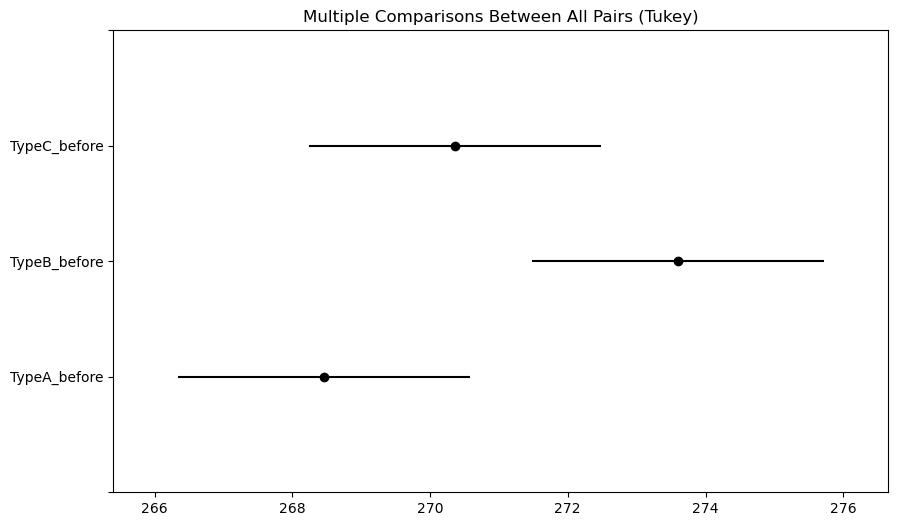

In [12]:
# 사후검정: Tukey HSD (Honest Significant Difference)

posthoc = pairwise_tukeyhsd(df2['value'], 
                            df2['variable'], 
                            alpha=0.05)  
# pairwise_tukeyhsd() 함수는 ANOVA에서 유의미한 평균 차이가 발견된 이후,
# **어떤 그룹 간에 차이가 있는지를 구체적으로 확인하기 위한 사후검정(post-hoc test)을 수행함**
# df2['value']: 비교 대상이 되는 측정값 (종속 변수)
# df2['variable']: 그룹을 구분하는 범주형 독립 변수 (예: TypeA_before 등)
# alpha=0.05: 유의수준 0.05 설정 → p < 0.05일 경우 그룹 간 평균 차이가 통계적으로 유의함을 의미함

print(posthoc)  
# 사후검정 결과를 표 형식으로 출력하는 명령문
# 각 그룹쌍 간 평균 차이, p-value, 신뢰구간, 유의성 여부(reject=True/False) 등을 포함함

fig = posthoc.plot_simultaneous()  
# Tukey HSD 결과를 시각적으로 보여주는 그래프를 생성하는 명령문
# 각 그룹쌍의 평균 차이 및 신뢰구간을 막대 그래프로 시각화함
# 신뢰구간이 0을 포함하지 않으면 → 해당 그룹쌍은 유의미한 평균 차이를 가진다는 해석 가능


### Tukey HSD 사후검정 결과 해석표

| 비교 그룹 | 평균 차이 (meandiff) | p-value | 95% 신뢰구간 (하한 ~ 상한) | 유의성 (reject) | 해석 요약 |
| --- | --- | --- | --- | --- | --- |
| **TypeA_before vs TypeB_before** | **+5.14** | **0.0129** | **0.9038 ~ 9.3762** | **True** | **유의한 차이 있음** (TypeB가 평균적으로 더 큼) |
| TypeA_before vs TypeC_before | +1.90 | 0.5392 | -2.3362 ~ 6.1362 | False | 유의한 차이 없음 |
| TypeB_before vs TypeC_before | -3.24 | 0.1696 | -7.4762 ~ 0.9962 | False | 유의한 차이 없음 |

### 🧭 그래프 구성 설명

- **수평선(막대)**: 각 그룹의 **평균값 ± 95% 신뢰구간**
- **● 점**: 각 그룹의 **실제 평균값**
- **x축**: 평균값의 수치 (예: 비거리, 측정값 등)
- **y축**: 그룹 이름 (TypeA_before, TypeB_before, TypeC_before)

---

### ✅ 해석 핵심: 신뢰구간이 겹치는가?

| 그룹 | 신뢰구간 간격 | 겹침 여부 | 해석 요약 |
| --- | --- | --- | --- |
| **TypeA_before** | 266.3 ~ 270.3 | 겹치지 않음 ↔ TypeB_before | ✔ 평균 차이 유의미함 |
| **TypeB_before** | 271.5 ~ 275.6 | 겹침 ↔ TypeC_before | ✘ 평균 차이 유의하지 않음 |
| **TypeC_before** | 268.5 ~ 272.4 | 겹침 ↔ TypeA_before | ✘ 평균 차이 유의하지 않음 |

📌 **TypeA_before**의 신뢰구간은 **TypeB_before**와 겹치지 않음 → 유의한 차이 존재

📌 나머지 조합은 신뢰구간이 서로 겹치므로 유의한 차이 없음